In [24]:
import numpy as np

X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8],
    [9],
    [10]
])

y = np.array([
    0,
    0,
    0,
    0,
    0,
    1,
    1,
    1,
    1,
    1
])

print("X:")
print(X)

print("\ny:")
print(y)

X:
[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]

y:
[0 0 0 0 0 1 1 1 1 1]


In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X,y)

print("Coefficient: ",model.coef_)
print("Intercept: ",model.intercept_)

Coefficient:  [[1.18606406]]
Intercept:  [-6.52322638]


In [26]:
probabilities = model.predict_proba(X)
print("Probabilities: ",probabilities)

Probabilities:  [[0.99521352 0.00478648]
 [0.98449701 0.01550299]
 [0.95096926 0.04903074]
 [0.85556965 0.14443035]
 [0.64403166 0.35596834]
 [0.3559106  0.6440894 ]
 [0.14439923 0.85560077]
 [0.049019   0.950981  ]
 [0.01549914 0.98450086]
 [0.00478528 0.99521472]]


In [27]:
predictions = model.predict(X)
print("Predictions: ",predictions)

Predictions:  [0 0 0 0 0 1 1 1 1 1]


In [28]:
from sklearn.metrics import accuracy_score

accuracy_score = accuracy_score(y,predictions)
print("Accuracy : ",accuracy_score)

Accuracy :  1.0


In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y,predictions)

print("Confusion Matrix :",cm)

Confusion Matrix : [[5 0]
 [0 5]]


In [30]:
from sklearn.metrics import precision_score,recall_score,f1_score

precision = precision_score(y,predictions)
recall = recall_score(y,predictions)
f1 = f1_score(y,predictions)

print("Precision : ",precision)
print("Recall : ",recall)
print("F1 score: ",f1)

Precision :  1.0
Recall :  1.0
F1 score:  1.0


In [31]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("X_train: ",X_train)
print("X_test: ",X_test)
print("y_train: ",y_train)
print("y_test: ",y_test)

X_train:  [[ 6]
 [ 1]
 [ 8]
 [ 3]
 [10]
 [ 5]
 [ 4]
 [ 7]]
X_test:  [[9]
 [2]]
y_train:  [1 0 1 0 1 0 0 1]
y_test:  [1 0]


In [32]:
model = LogisticRegression()

model.fit(X_train,y_train)

print("Coefficient: ",model.coef_)
print("Intercept: ",model.intercept_)

Coefficient:  [[1.14270903]]
Intercept:  [-6.28495636]


In [33]:
test_predictions = model.predict(X_test)

print("Actual value : ",y_test)
print("Predicted value : ",test_predictions)

Actual value :  [1 0]
Predicted value :  [1 0]


In [34]:
from sklearn.metrics import accuracy_score

accuracy_score = accuracy_score(y_test,test_predictions)
print("Accuracy : ",accuracy_score)

Accuracy :  1.0


In [35]:
test_probabilities = model.predict_proba(X_test)

print("Test Probabilities : ",test_probabilities)

Test Probabilities :  [[0.01799637 0.98200363]
 [0.98200563 0.01799437]]


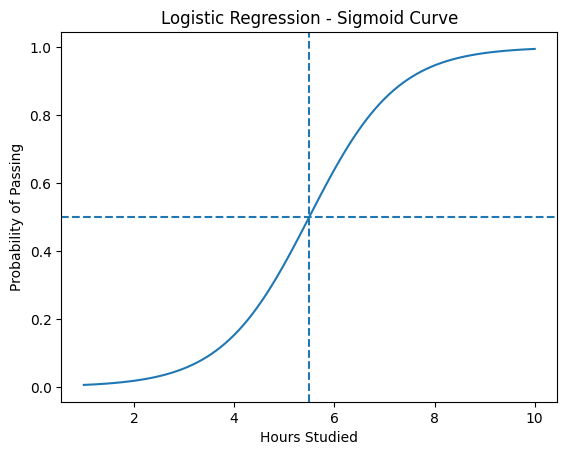

In [36]:
import numpy as np
import matplotlib.pyplot as plt

x_values = np.linspace(1,10,100)

z = model.intercept_[0] + model.coef_[0][0] * x_values

probabilities = 1 / (1 + np.exp(-z))

plt.plot(x_values,probabilities)
plt.axhline(0.5, linestyle="--")
plt.axvline(5.5, linestyle="--")

plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression - Sigmoid Curve")

plt.show()

In [37]:
test_probabilities = model.predict_proba(X_test)[:, 1]

threshold = 0.7

custom_predictions = (test_probabilities >= threshold).astype(int)

print("Test Probabilities: ",test_probabilities)
print("Custom Predictions: ",custom_predictions)

Test Probabilities:  [0.98200363 0.01799437]
Custom Predictions:  [1 0]


In [38]:

all_probabilities = model.predict_proba(X)[:, 1]

pred_05 = (all_probabilities >= 0.5).astype(int)
pred_09 = (all_probabilities >= 0.9).astype(int)

print("Pass probabilities:")
print(all_probabilities)

print("\nPredictions with threshold 0.5:")
print(pred_05)

print("\nPredictions with threshold 0.9:")
print(pred_09)

Pass probabilities:
[0.00581058 0.01799437 0.05432937 0.15263006 0.36091126 0.63906258
 0.84735527 0.9456648  0.98200363 0.99418876]

Predictions with threshold 0.5:
[0 0 0 0 0 1 1 1 1 1]

Predictions with threshold 0.9:
[0 0 0 0 0 0 0 1 1 1]
